# 6CS012 - Worksheet 1
## Image Compression and Decompression using PCA
**Prepared by:** Siman Giri | **Module:** 6CS012 - Artificial Intelligence and Machine Learning



In [1]:
# Install required libraries (run once)
!pip install Pillow -q
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
print('✅ All libraries loaded!')

✅ All libraries loaded!


---
#Section 2.1 — Exercise 1: RGB Image Processing
Tasks: Read & display, top-left 100x100, R/G/B channels, modify top-left pixels

In [4]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

IMAGE_PATH = '/content/drive/MyDrive/AI and ML/imageworkshop.jpg

img_pil = Image.open(IMAGE_PATH).convert('RGB')
img_array = np.array(img_pil)

print(f'Image shape: {img_array.shape}')
print(f'Data type : {img_array.dtype}')
print(f'Min pixel : {img_array.min()} | Max pixel: {img_array.max()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Image shape: (680, 1200, 3)
Data type : uint8
Min pixel : 0 | Max pixel: 255


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


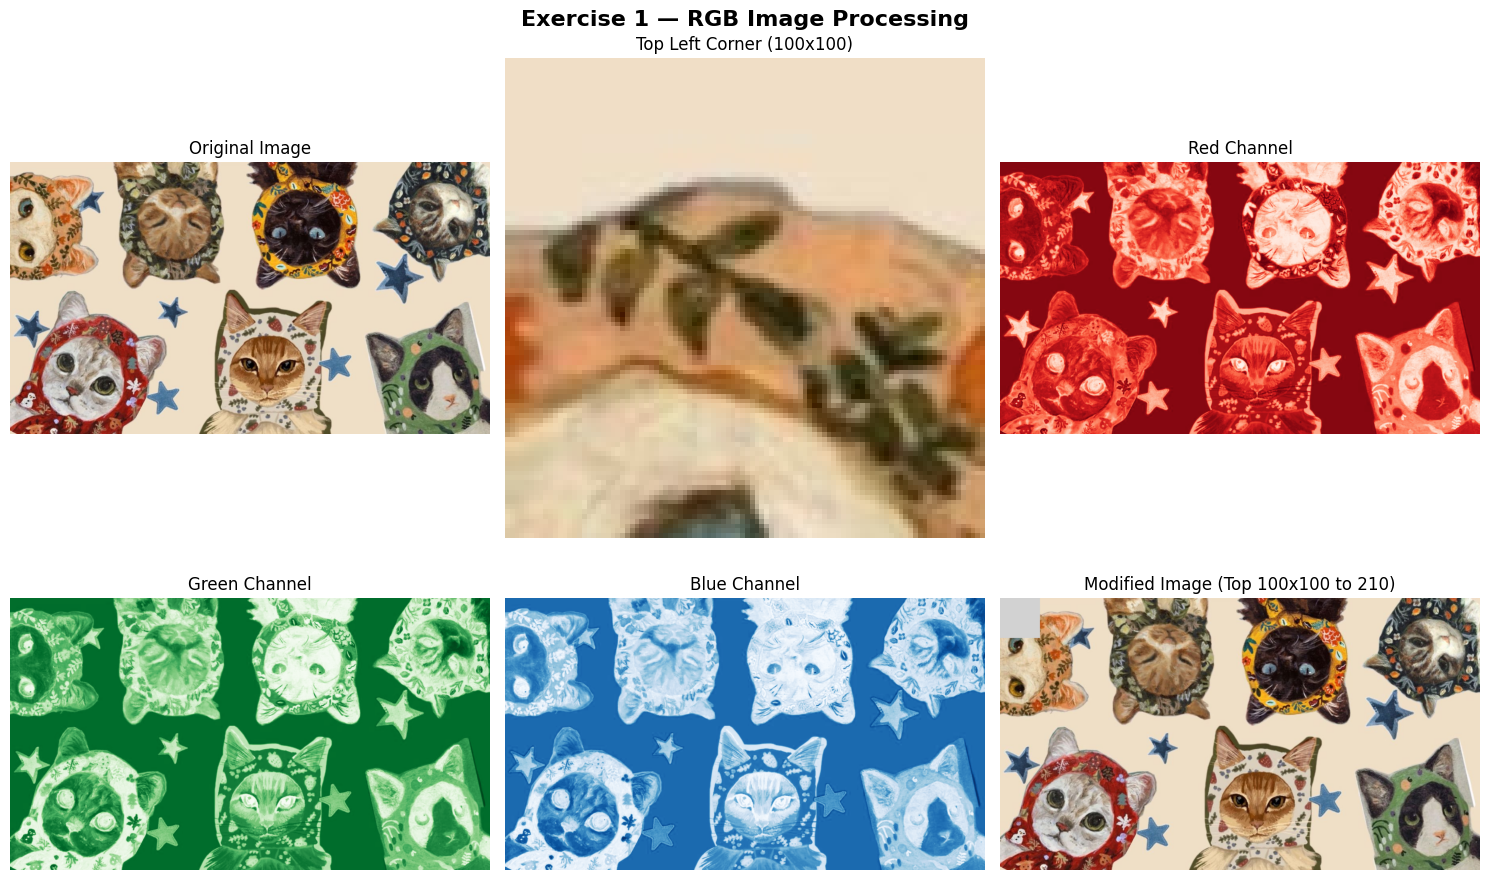

   R channel shape: (680, 1200)
   G channel shape: (680, 1200)
   B channel shape: (680, 1200)
   Modified top-left pixel value: [210 210 210]


In [7]:
# ── Task 1: Display original image
# ── Task 2: Display top-left 100x100 corner
# ── Task 3: Show R, G, B channels separately with colormaps
# ── Task 4: Modify top-left 100x100 to pixel value 210

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Exercise 1 — RGB Image Processing', fontsize=16, fontweight='bold')

# Task 1 — Original Image
axes[0, 0].imshow(img_array)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# Task 2 — Top-left 100x100 using NumPy array indexing
top_left = img_array[:100, :100]
axes[0, 1].imshow(top_left)
axes[0, 1].set_title('Top Left Corner (100x100)')
axes[0, 1].axis('off')

# Task 3 — Separate R, G, B channels using NumPy
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

axes[0, 2].imshow(R, cmap='Reds')
axes[0, 2].set_title('Red Channel')
axes[0, 2].axis('off')

axes[1, 0].imshow(G, cmap='Greens')
axes[1, 0].set_title('Green Channel')
axes[1, 0].axis('off')

axes[1, 1].imshow(B, cmap='Blues')
axes[1, 1].set_title('Blue Channel')
axes[1, 1].axis('off')

# Task 4 — Modify top-left 100x100 pixels to value 210 (light gray)
img_modified = img_array.copy()            # Always work on a copy!
img_modified[:100, :100] = 210            # Set all 3 channels to 210
axes[1, 2].imshow(img_modified)
axes[1, 2].set_title('Modified Image (Top 100x100 to 210)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print(f'   R channel shape: {R.shape}')
print(f'   G channel shape: {G.shape}')
print(f'   B channel shape: {B.shape}')
print(f'   Modified top-left pixel value: {img_modified[0, 0]}')

---
#Section 2.2 — Exercise 2: Grayscale Image Processing
Tasks: Load grayscale, middle section, threshold, rotate 90°, convert to RGB

In [10]:

img_gray_pil = Image.open(IMAGE_PATH).convert('L')
img_gray = np.array(img_gray_pil)

print(f'Grayscale image shape: {img_gray.shape}')
print(f'Min pixel: {img_gray.min()} | Max pixel: {img_gray.max()}')

Grayscale image shape: (680, 1200)
Min pixel: 0 | Max pixel: 255


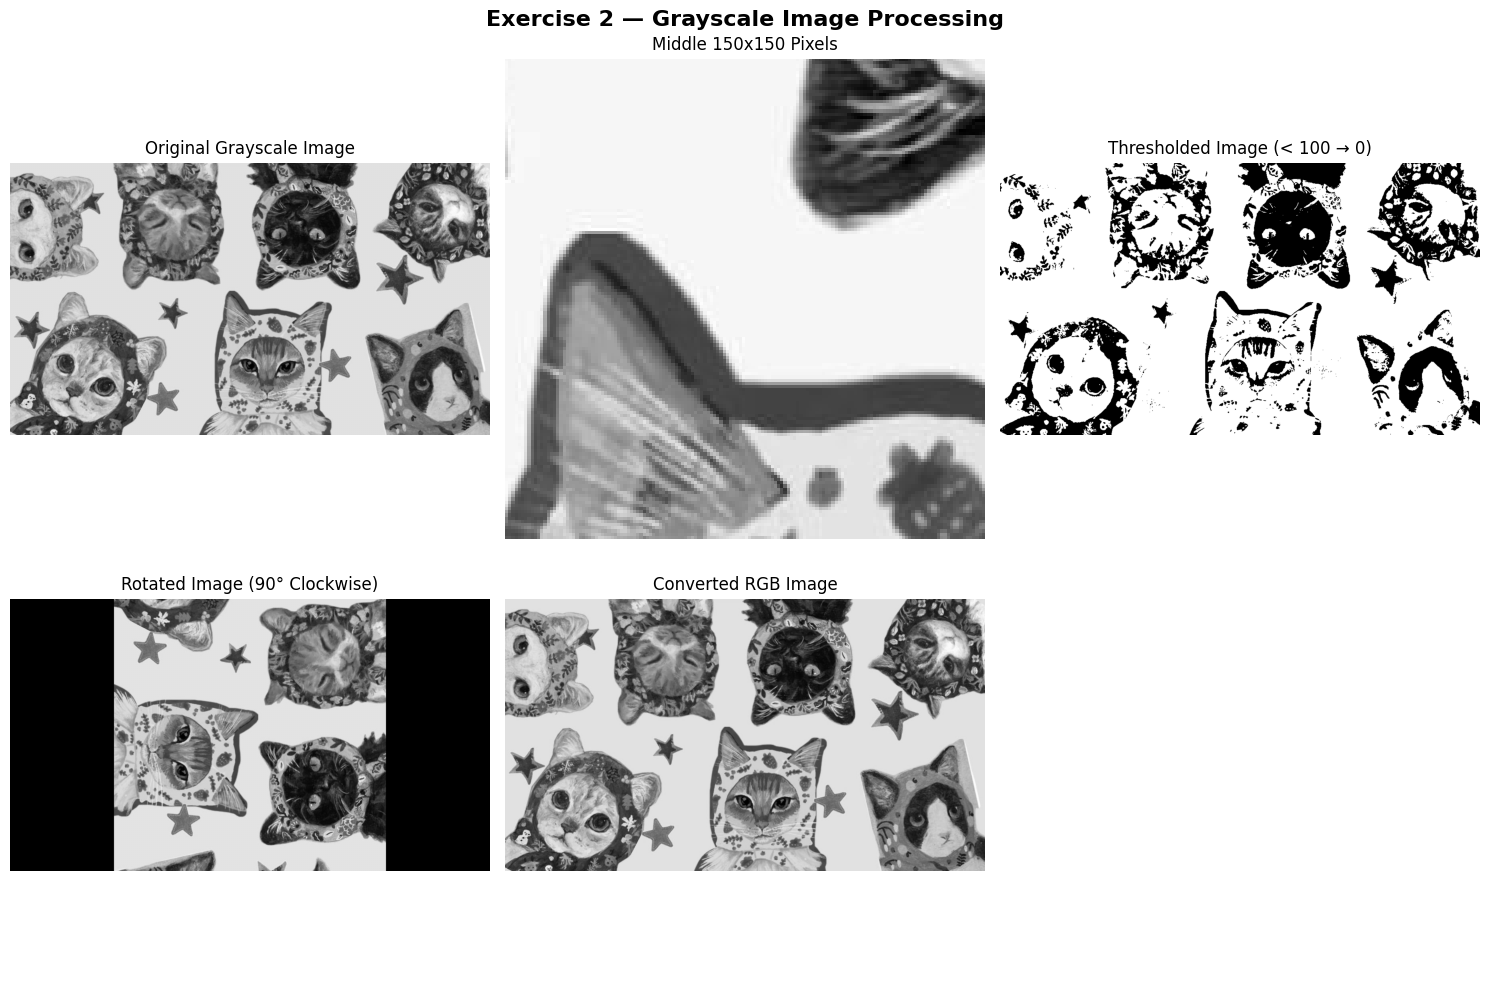

   Middle section shape   : (150, 150)
   Rotated image shape    : (680, 1200)
   Converted RGB shape    : (680, 1200, 3)
   Unique values in threshold: [  0 255]


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Exercise 2 — Grayscale Image Processing', fontsize=16, fontweight='bold')

# Task 1 — Display original grayscale image
axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title('Original Grayscale Image')
axes[0, 0].axis('off')

# Task 2 — Extract middle 150x150 section using NumPy array slicing
h, w = img_gray.shape
center_h, center_w = h // 2, w // 2
middle = img_gray[center_h - 75 : center_h + 75,
                  center_w - 75 : center_w + 75]    # 150x150 from center
axes[0, 1].imshow(middle, cmap='gray')
axes[0, 1].set_title('Middle 150x150 Pixels')
axes[0, 1].axis('off')

# Task 3 — Apply threshold: values < 100 → 0, values >= 100 → 255
img_thresh = img_gray.copy()
img_thresh[img_thresh < 100] = 0
img_thresh[img_thresh >= 100] = 255
axes[0, 2].imshow(img_thresh, cmap='gray')
axes[0, 2].set_title('Thresholded Image (< 100 → 0)')
axes[0, 2].axis('off')

# Task 4 — Rotate 90 degrees clockwise
# Pillow rotate() uses counter-clockwise, so use -90 for clockwise
img_rotated_pil = img_gray_pil.rotate(-90)
img_rotated = np.array(img_rotated_pil)
# Alternatively with NumPy: np.rot90(img_gray, k=-1) or np.rot90(img_gray, k=3)
axes[1, 0].imshow(img_rotated, cmap='gray')
axes[1, 0].set_title('Rotated Image (90° Clockwise)')
axes[1, 0].axis('off')

# Task 5 — Convert grayscale to RGB (replicate channel across R, G, B)
img_rgb_converted = np.stack([img_gray, img_gray, img_gray], axis=-1)  # shape: (H, W, 3)
axes[1, 1].imshow(img_rgb_converted)
axes[1, 1].set_title('Converted RGB Image')
axes[1, 1].axis('off')

# Hide empty subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print(f'   Middle section shape   : {middle.shape}')
print(f'   Rotated image shape    : {img_rotated.shape}')
print(f'   Converted RGB shape    : {img_rgb_converted.shape}')
print(f'   Unique values in threshold: {np.unique(img_thresh)}')

---
#Section 3 — Image Compression Using PCA (From Scratch)

We will build PCA from scratch using the **Eigendecomposition method** — no sklearn!

**Steps:**
1. Load and prepare data (grayscale, standardize)
2. Compute covariance matrix → Eigenvalues & Eigenvectors
3. Sort and select top-k principal components
4. Reconstruct image with different k values
5. Compare results

In [13]:

img_data = img_gray.astype(np.float64)

print(f'Image shape    : {img_data.shape}')
print(f'Data type      : {img_data.dtype}')
print(f'Pixel range    : [{img_data.min():.1f}, {img_data.max():.1f}]')

mean = np.mean(img_data, axis=0)
img_centered = img_data - mean
print(f'\nMean shape     : {mean.shape}')
print(f'Centered shape : {img_centered.shape}')
print(f'Centered mean  : {np.mean(img_centered, axis=0).mean():.6f}  (should be ~0)')

Image shape    : (680, 1200)
Data type      : float64
Pixel range    : [0.0, 255.0]

Mean shape     : (1200,)
Centered shape : (680, 1200)
Centered mean  : -0.000000  (should be ~0)


In [14]:
n_samples = img_centered.shape[0]


cov_matrix = np.dot(img_centered.T, img_centered) / (n_samples - 1)

print(f'Covariance matrix shape: {cov_matrix.shape}')

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)


print(f'Eigenvalues shape  : {eigenvalues.shape}')
print(f'Eigenvectors shape : {eigenvectors.shape}')


sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted  = eigenvalues[sorted_indices]
eigenvectors_sorted = eigenvectors[:, sorted_indices]

print(f'\nTop 5 eigenvalues: {eigenvalues_sorted[:5].round(2)}')
print(f'Smallest 5       : {eigenvalues_sorted[-5:].round(2)}')

Covariance matrix shape: (1200, 1200)
Eigenvalues shape  : (1200,)
Eigenvectors shape : (1200, 1200)

Top 5 eigenvalues: [1390555.92  626044.03  347305.55  330960.78  213441.37]
Smallest 5       : [-0. -0. -0. -0. -0.]


80% variance explained by 14 components
90% variance explained by 28 components
95% variance explained by 49 components
99% variance explained by 125 components


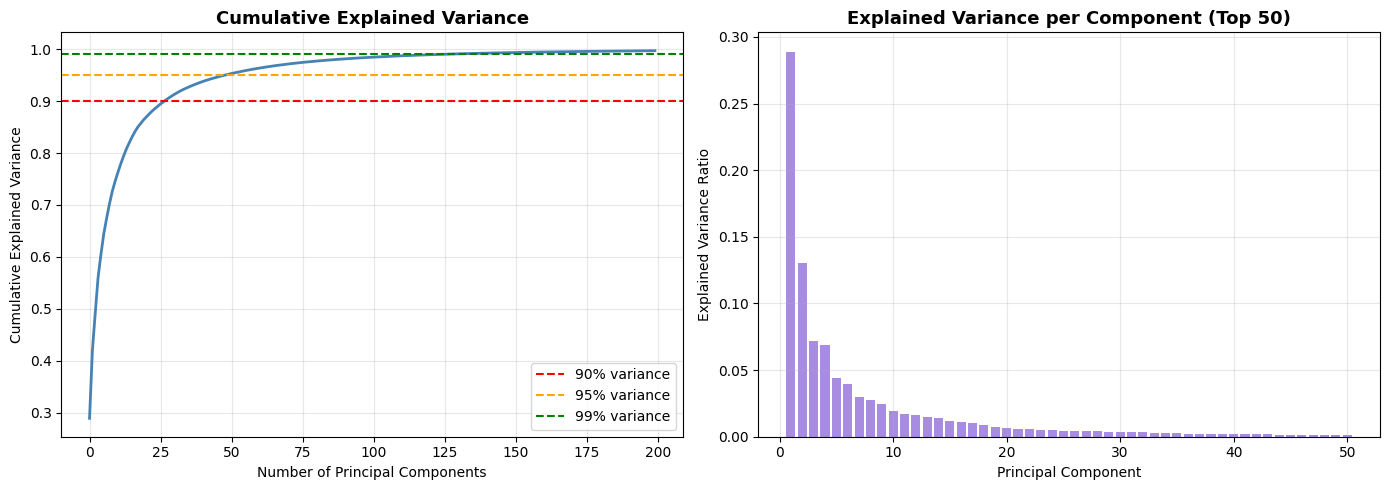

In [15]:
total_variance = np.sum(eigenvalues_sorted)
explained_variance_ratio = eigenvalues_sorted / total_variance
cumulative_variance = np.cumsum(explained_variance_ratio)

for threshold in [0.80, 0.90, 0.95, 0.99]:
    k = np.argmax(cumulative_variance >= threshold) + 1
    print(f'{threshold*100:.0f}% variance explained by {k} components')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cumulative_variance[:200], color='steelblue', linewidth=2)
axes[0].axhline(y=0.90, color='red', linestyle='--', label='90% variance')
axes[0].axhline(y=0.95, color='orange', linestyle='--', label='95% variance')
axes[0].axhline(y=0.99, color='green', linestyle='--', label='99% variance')
axes[0].set_title('Cumulative Explained Variance', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Principal Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(range(1, 51), explained_variance_ratio[:50], color='mediumpurple', alpha=0.8)
axes[1].set_title('Explained Variance per Component (Top 50)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
def pca_compress_reconstruct(img_centered, eigenvectors_sorted, mean, k):
    top_k_vectors = eigenvectors_sorted[:, :k]
    compressed = np.dot(img_centered, top_k_vectors)
    reconstructed = np.dot(compressed, top_k_vectors.T) + mean
    reconstructed = np.clip(reconstructed, 0, 255).astype(np.uint8)
    return reconstructed


test_reconstruction = pca_compress_reconstruct(img_centered, eigenvectors_sorted, mean, k=50)
print(f'Reconstructed image shape : {test_reconstruction.shape}')
print(f'Pixel range               : [{test_reconstruction.min()}, {test_reconstruction.max()}]')

Reconstructed image shape : (680, 1200)
Pixel range               : [0, 255]


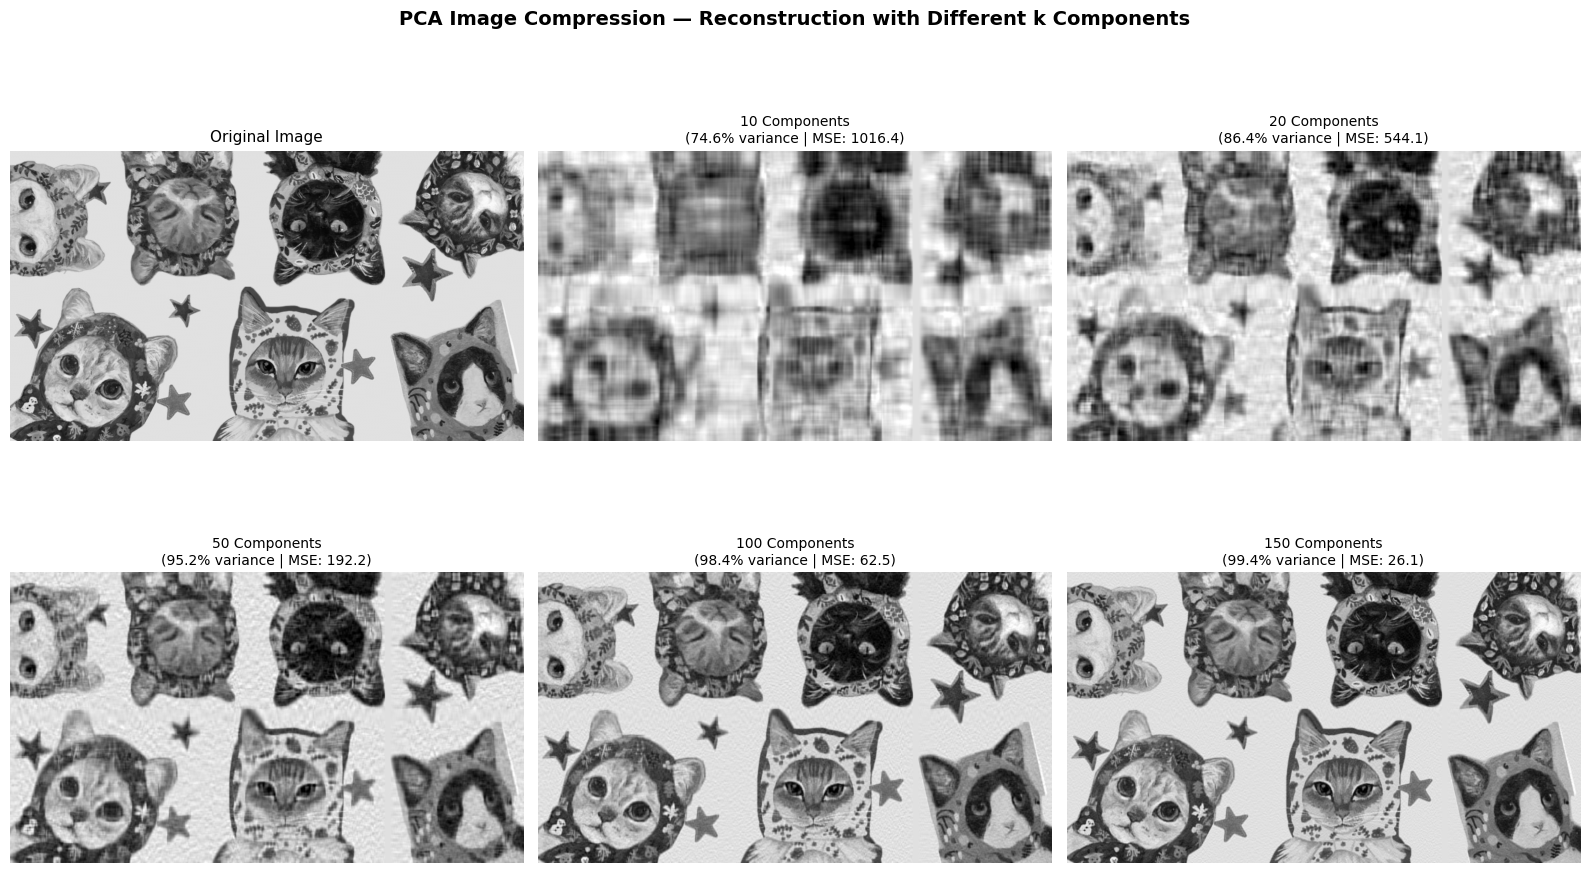


k Components      Variance Explained          MSE  Compression Ratio
10                            74.56%      1016.39             43.40x
20                            86.39%       544.10             21.70x
50                            95.20%       192.22              8.68x
100                           98.45%        62.48              4.34x
150                           99.36%        26.12              2.89x


In [17]:
k_values = [10, 20, 50, 100, 150]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('PCA Image Compression — Reconstruction with Different k Components',
             fontsize=14, fontweight='bold')

axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title('Original Image', fontsize=11)
axes[0, 0].axis('off')

plot_positions = [(0,1), (0,2), (1,0), (1,1), (1,2)]

for idx, k in enumerate(k_values):
    reconstructed = pca_compress_reconstruct(img_centered, eigenvectors_sorted, mean, k)
    var_explained = cumulative_variance[k-1] * 100
    mse = np.mean((img_gray.astype(float) - reconstructed.astype(float))**2)
    r, c = plot_positions[idx]
    axes[r, c].imshow(reconstructed, cmap='gray')
    axes[r, c].set_title(f'{k} Components\n({var_explained:.1f}% variance | MSE: {mse:.1f})',
                          fontsize=10)
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print(f"{'k Components':<15} {'Variance Explained':>20} {'MSE':>12} {'Compression Ratio':>18}")
print("=" * 60)
original_size = img_gray.shape[0] * img_gray.shape[1]
for k in k_values:
    reconstructed = pca_compress_reconstruct(img_centered, eigenvectors_sorted, mean, k)
    var_exp = cumulative_variance[k-1] * 100
    mse = np.mean((img_gray.astype(float) - reconstructed.astype(float))**2)
    compressed_size = img_gray.shape[0] * k + img_gray.shape[1] * k
    ratio = original_size / compressed_size
    print(f"{k:<15} {var_exp:>19.2f}% {mse:>12.2f} {ratio:>17.2f}x")
print("=" * 60)